## Singular Value Decomposition

Singular Value Decomposition is an essential technique used to decompose and analyse rectangular matrices. This helps in spectral analysis of the image/matrix.

In [52]:
from PIL import Image
import numpy as np 
import matplotlib.pyplot as plt 

In [53]:
IMAGE_PATH = 'D:/python/deep-learning/numpy-basics/image.jpg'
image = Image.open(IMAGE_PATH)
gray_scale = image.convert("L")
A = np.array(gray_scale)

When performing the Singular Value Decomposition (SVD) of an image matrix \( A \), we obtain three matrices:

\[
A = U \Sigma V^\top
\]

- **\( U \)** contains the eigenvectors of the matrix \( A A^\top \).
- **\( V \)** contains the eigenvectors of the matrix \( A^\top A \).
- **\( \Sigma \)** is a diagonal matrix whose entries are the singular values of \( A \).

The singular values are defined as the square roots of the eigenvalues of the symmetric, positive semi-definite matrices \( A A^\top \) (or equivalently \( A^\top A \)).


In [54]:
U, S, Vt = np.linalg.svd(A)

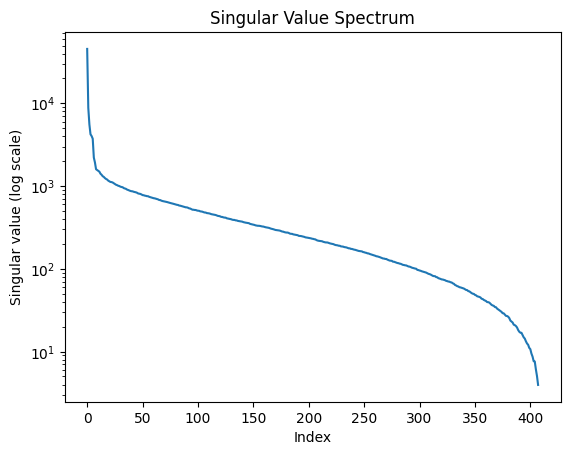

In [55]:
plt.semilogy(S)
plt.xlabel("Index")
plt.ylabel("Singular value (log scale)")
plt.title("Singular Value Spectrum")
plt.show()

In [56]:
def relative_fro_error(A, A_k):
    return np.linalg.norm(A - A_k, 'fro') / np.linalg.norm(A, 'fro')

def reconstruct(A, k):
    U, S, Vt = np.linalg.svd(A)
    Uk = U[:, :k]
    Sk = np.diag(S[:k])
    Vk = Vt[:k, :]
    return Uk @ Sk @ Vk

In [46]:
k = [1, 50, 150, 250, 350, min(A.shape)]
k_len = len(k)
A_store = []
for i in range(k_len):
    A_k = reconstruct(A, k[i])
    print(relative_fro_error(A, A_k))
    A_store.append(A_k)

0.32937513660004136
0.1254300098632242
0.05588461001276138
0.02199946440881739
0.0046774933029685465
1.7701574852595282e-15


In [47]:
vmin = A.min()
vmax = A.max()

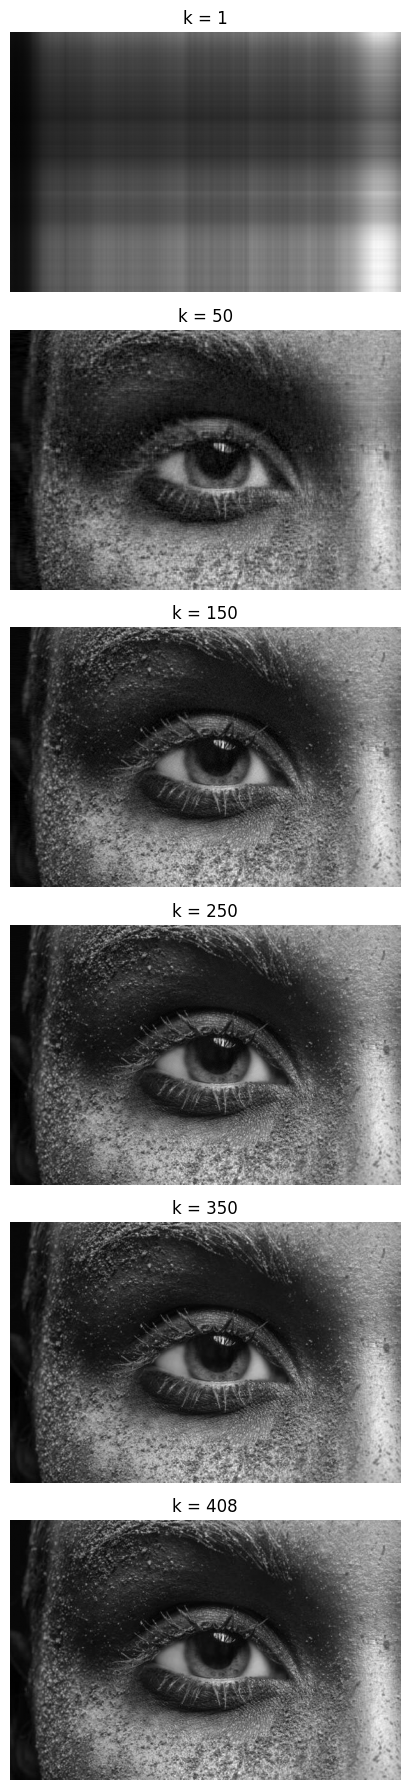

In [48]:
plt.figure(figsize=(6, 3 * k_len))

for i in range(k_len):
    plt.subplot(k_len, 1, i + 1)
    plt.imshow(A_store[i], cmap='gray', vmin=vmin, vmax=vmax)
    plt.axis('off')
    plt.title(f"k = {k[i]}")

plt.tight_layout()
plt.show()


In [49]:
def reconstruct_subset(A, indices):
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    A_rec = np.zeros_like(A, dtype=float)
    
    for i in indices:
        A_rec += S[i] * np.outer(U[:, i], Vt[i, :])
    
    return A_rec


In [50]:
k = 50
U, S, Vt = np.linalg.svd(A, full_matrices=False)
r = len(S)

first_50 = list(range(0, 50))
last_50  = list(range(r - 50, r))

A_first = reconstruct_subset(A, first_50)
A_last  = reconstruct_subset(A, last_50)
print(relative_fro_error(A, A_first))
print(relative_fro_error(A, A_last))


0.1254300098632242
0.9999926779995396


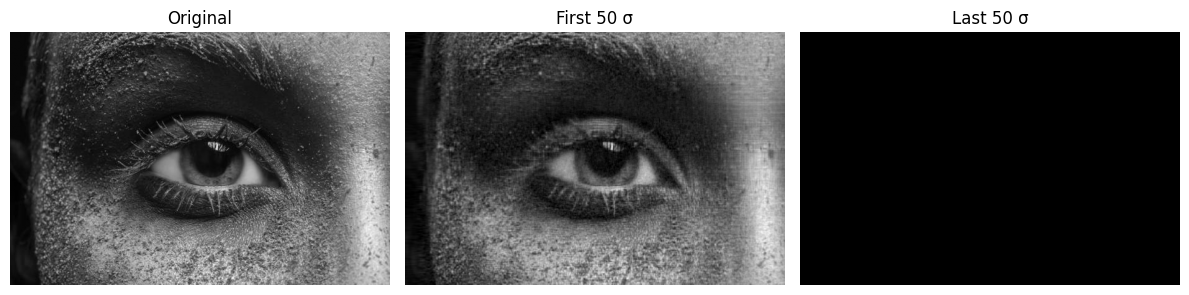

In [51]:
vmin, vmax = A.min(), A.max()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(A, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(A_first, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("First 50 σ")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(A_last, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("Last 50 σ")
plt.axis('off')

plt.tight_layout()
plt.show()
